In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os

In [5]:
file_path = os.path.join('..', 'data', 'raw', 'yfinance_data','Data','AAPL.csv')
stock_df=pd.read_csv(file_path)

stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df.set_index('Date', inplace=True)

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in numeric_cols:
    stock_df[col] = pd.to_numeric(stock_df[col], errors='coerce')

stock_df = stock_df.ffill()
stock_df.head()


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [8]:
#Calculating SMA and EMA

import talib

# 1. Simple Moving Average (SMA) - 20-day window (Short-term trend)
stock_df['SMA_20'] = talib.SMA(stock_df['Close'], timeperiod=20)

# 2. Simple Moving Average (SMA) - 50-day window (Medium-term trend)
stock_df['SMA_50'] = talib.SMA(stock_df['Close'], timeperiod=50)

# 3. Exponential Moving Average (EMA) - 20-day window
# EMA reacts faster to recent price changes than SMA
stock_df['EMA_20'] = talib.EMA(stock_df['Close'], timeperiod=20)

# 4. Check the results
# Note: The first 19 rows will be 'NaN' because you need 20 days of data to calculate an average!
print(stock_df[['Close', 'SMA_20', 'EMA_20']].tail())

                 Close      SMA_20      EMA_20
Date                                          
2023-12-22  191.788757  191.856618  191.510231
2023-12-26  191.243912  192.018094  191.484867
2023-12-27  191.342972  192.154308  191.471353
2023-12-28  191.768951  192.362839  191.499696
2023-12-29  190.728775  192.490633  191.426275


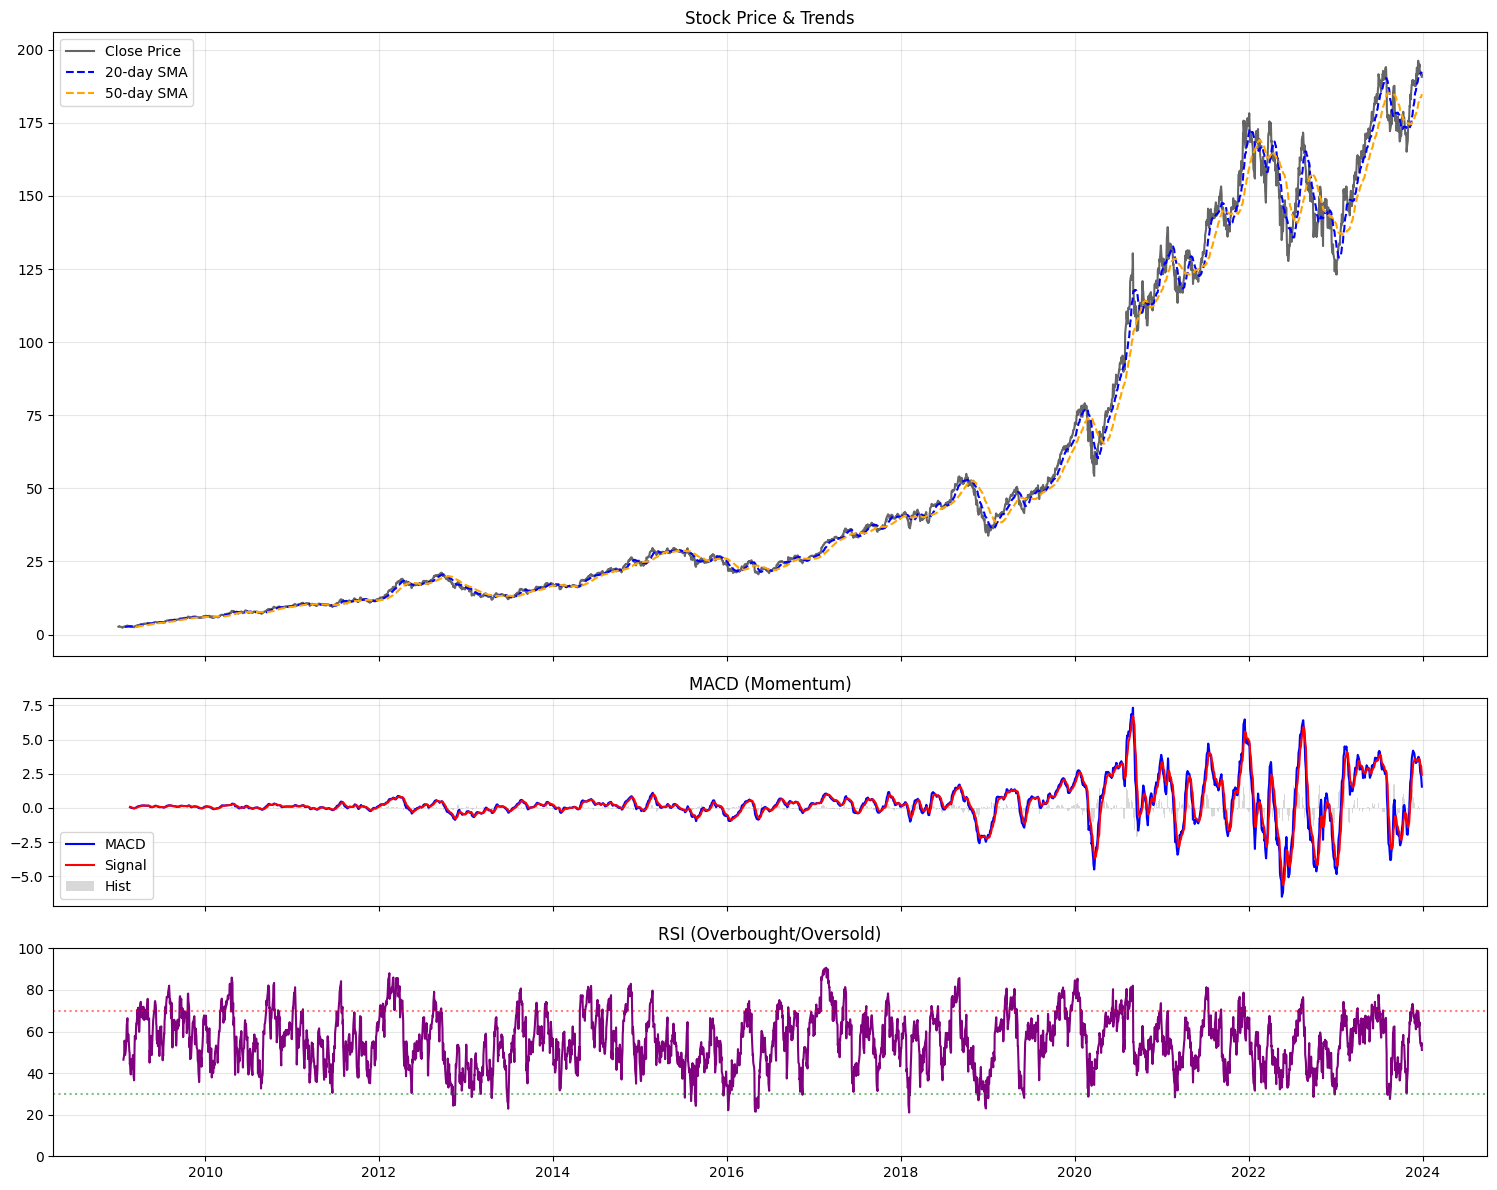

In [9]:
import talib
import matplotlib.pyplot as plt

# --- 1. Compute RSI and MACD (Using TA-Lib) ---
# RSI: Relative Strength Index
stock_df['RSI'] = talib.RSI(stock_df['Close'], timeperiod=14)

# MACD: Moving Average Convergence Divergence
# Returns: macd (line), macdsignal (signal line), macdhist (histogram)
macd, macdsignal, macdhist = talib.MACD(stock_df['Close'], 
                                        fastperiod=12, 
                                        slowperiod=26, 
                                        signalperiod=9)
stock_df['MACD'] = macd
stock_df['MACD_Signal'] = macdsignal
stock_df['MACD_Hist'] = macdhist

# --- 2. Advanced Visualization: The Three-Panel Dashboard ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True, 
                                     gridspec_kw={'height_ratios': [3, 1, 1]})

# Panel 1: Price and Moving Averages
ax1.plot(stock_df.index, stock_df['Close'], label='Close Price', color='black', alpha=0.6)
ax1.plot(stock_df.index, stock_df['SMA_20'], label='20-day SMA', color='blue', linestyle='--')
ax1.plot(stock_df.index, stock_df['SMA_50'], label='50-day SMA', color='orange', linestyle='--')
ax1.set_title('Stock Price & Trends')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Panel 2: MACD
ax2.plot(stock_df.index, stock_df['MACD'], label='MACD', color='blue')
ax2.plot(stock_df.index, stock_df['MACD_Signal'], label='Signal', color='red')
ax2.bar(stock_df.index, stock_df['MACD_Hist'], label='Hist', color='gray', alpha=0.3)
ax2.set_title('MACD (Momentum)')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# Panel 3: RSI
ax3.plot(stock_df.index, stock_df['RSI'], label='RSI', color='purple')
ax3.axhline(70, color='red', linestyle=':', alpha=0.5) # Overbought line
ax3.axhline(30, color='green', linestyle=':', alpha=0.5) # Oversold line
ax3.set_title('RSI (Overbought/Oversold)')
ax3.set_ylim(0, 100)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()